In [1]:
import os, sys, gc, json, random, re, copy, multiprocessing as mp
from functools import partial
from pathlib import Path

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import gurobipy as gp
from gurobipy import Model, GRB, quicksum

import deap.base as deap_base
import deap.creator as deap_creator
from deap import tools, algorithms
from deap.tools.emo import sortNondominated, assignCrowdingDist

from scipy.stats import norm, qmc
from tqdm.auto import tqdm

# Jupyter
gc.collect()
%matplotlib inline

# Print control
VERBOSE = True

## Load data

In [2]:
from inputs import input_files_kor, input_files_uk

REGION = "uk"  # or "kor"
input_files = input_files_kor if REGION == "kor" else input_files_uk

jload = lambda p: json.loads(Path(p).read_text(encoding="utf-8"))
to_tuple_dict = lambda d: {k: tuple(v) for k, v in d.items()}

nodes = to_tuple_dict(jload(input_files["nodes"]))

_edges = jload(input_files["edges"])
assert all(len(v) == 3 for v in _edges.values()), "edges.json must be ['ni','nj', meta]"
edges = {eid: (v[0], v[1]) for eid, v in _edges.items()}
edge_meta = {eid: v[2] for eid, v in _edges.items()}

arcs = list(edges.values())
arc_distance    = {k: float(v) for k, v in jload(input_files["arc_distance"]).items()}
intact_capacity = {k: float(v) for k, v in jload(input_files["intact_capacity"]).items()}
probs = jload(input_files["probs"]) if "probs" in input_files else {}

if VERBOSE:
    print(f"#nodes={len(nodes)}, #edges={len(edges)}, #arcs={len(arcs)}")
    print(f"arc_distance={len(arc_distance)}, intact_capacity={len(intact_capacity)}, probs={len(probs)}")
    print("edge_meta examples:", list(edge_meta.items())[:5])

#nodes=61, #edges=214, #arcs=214
arc_distance=214, intact_capacity=214, probs=214
edge_meta examples: [('e1', 14), ('e1r', 14), ('e2', 14), ('e2r', 14), ('e3', 8)]


In [3]:
# Data: demand
demand_raw = jload(input_files["demand"])

demand_dict   = {}
max_distance  = {}
avg_velo      = 149.0   # km/h
delay_time    = 180.0   # minutes

for idx, item in enumerate(demand_raw, start=1):
    k = f"k{idx}"
    demand_dict[k] = {
        "origin":      item["origin_name"],
        "destination": item["destination_name"],
        "amount":      float(item["journeys"]),
        "distance":    float(item["distance"]),
    }
    extra = (avg_velo * delay_time / 60.0) * 1000.0
    max_distance[k] = demand_dict[k]["distance"] + extra

if VERBOSE:
    ex = list(demand_dict.items())[:3]
    print(f"#OD={len(demand_dict)}; examples:\n" + "\n".join(f"  {k}: {v}" for k, v in ex))

#OD=720; examples:
  k1: {'origin': 'n46', 'destination': 'n35', 'amount': 194.67, 'distance': 10926.652}
  k2: {'origin': 'n46', 'destination': 'n31', 'amount': 194.25, 'distance': 19121.641}
  k3: {'origin': 'n46', 'destination': 'n30', 'amount': 1.82, 'distance': 21604.970999999998}


## System function

In [4]:
# System function: unweighted reachability with shortest path
def shortestpath_systemfunc(arcs, edges, arc_capacity, demand):
    G = nx.DiGraph()
    for e, (i, j) in edges.items():
        cap = float(arc_capacity.get(e, 0.0))
        if cap > 0.0:
            G.add_edge(i, j, capacity=cap, link_id=e)

    total_demand_pd = sum(float(info["amount"]) * float(info["distance"]) for info in demand.values())
    expected_loss = 0.0

    for k, info in demand.items():
        o, d = info["origin"], info["destination"]
        amt, base_dist = float(info["amount"]), float(info["distance"])
        if (o not in G) or (d not in G):
            expected_loss += amt * base_dist
            continue
        try:
            _ = nx.shortest_path(G, source=o, target=d)
        except nx.NetworkXNoPath:
            expected_loss += amt * base_dist

    return expected_loss, total_demand_pd

In [5]:
# System function: MCNF with distance cap and refund ratio (SOS2)
def MCNF_systemfunc(arcs, edges, arc_capacity, demand, max_distance, arc_distance, avg_velo: float = 149.0):
    edge_map = {v: k for k, v in edges.items()}

    # Piecewise points (minutes)
    T0, T1, T2, T3 = 15.0, 30.0, 60.0, 120.0
    DELTAS = [0.0, T0, T1, T2, T3]
    GAMMAS = [0.0, 0.25, 0.50, 0.75, 1.0]
    MCOUNT = len(DELTAS)

    # Minutes per meter
    ALPHA = 60.0 / (1000.0 * avg_velo)

    model = Model("MCNF")
    model.Params.OutputFlag = 0

    flow, unmet, delta, gamma, lam = {}, {}, {}, {}, {}
    nodes_set = set(n for a in arcs for n in a)

    for k in demand:
        unmet[k]  = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"u[{k}]")
        delta[k]  = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"delta[{k}]")
        gamma[k]  = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"gamma[{k}]")
        for m in range(MCOUNT):
            lam[k, m] = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"lam[{k},{m}]")
        for (i, j) in arcs:
            eid = edge_map.get((i, j))
            cap = float(arc_capacity.get(eid, 0.0))
            flow[k, i, j] = model.addVar(lb=0.0, ub=cap, vtype=GRB.CONTINUOUS, name=f"f[{k},{i},{j}]")

    model.update()

    out_o, dist_sum = {}, {}
    for k, info in demand.items():
        o = info["origin"]
        out_o[k] = quicksum(flow[k, i, j] for (i, j) in arcs if i == o)
        dist_sum[k] = quicksum(float(arc_distance[edge_map[(i, j)]]) * flow[k, i, j]
                               for (i, j) in arcs if (i, j) in edge_map)

    # Flow conservation
    for k, info in demand.items():
        o, d, amt = info["origin"], info["destination"], float(info["amount"])
        for n in nodes_set:
            inflow  = quicksum(flow[k, i, j] for (i, j) in arcs if j == n)
            outflow = quicksum(flow[k, i, j] for (i, j) in arcs if i == n)
            if n == o:
                model.addConstr(outflow - inflow == amt - unmet[k])
            elif n == d:
                model.addConstr(outflow - inflow == -amt + unmet[k])
            else:
                model.addConstr(outflow - inflow == 0.0)

    # Arc capacity
    for (i, j) in arcs:
        eid = edge_map.get((i, j))
        cap = float(arc_capacity.get(eid, 0.0))
        model.addConstr(quicksum(flow[k, i, j] for k in demand) <= cap)

    # Travel distance limit
    for k in demand:
        model.addConstr(dist_sum[k] <= float(max_distance[k]) * out_o[k])

    # Delay minutes and refund ratio
    for k, info in demand.items():
        d_plan = float(info["distance"])
        Dbar_k = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"Dbar[{k}]")
        model.addConstr(Dbar_k >= dist_sum[k] - d_plan * out_o[k])
        model.addConstr(delta[k] == ALPHA * Dbar_k)

    for k in demand:
        model.addConstr(quicksum(lam[k, m] for m in range(MCOUNT)) == out_o[k])
        model.addConstr(delta[k] == quicksum(DELTAS[m] * lam[k, m] for m in range(MCOUNT)))
        model.addConstr(gamma[k] == quicksum(GAMMAS[m] * lam[k, m] for m in range(MCOUNT)))
        model.addSOS(GRB.SOS_TYPE2, [lam[k, m] for m in range(MCOUNT)], DELTAS)

    # Objective
    obj = quicksum(float(info["distance"]) * (unmet[k] + gamma[k]) for k, info in demand.items())
    model.setObjective(obj, GRB.MINIMIZE)
    model.optimize()

    if model.Status != GRB.OPTIMAL:
        return None, None

    expected_loss = float(model.ObjVal)
    total_demand_pd = sum(float(info["amount"]) * float(info["distance"]) for info in demand.values())

    if VERBOSE:
        print(f"Expected Loss={expected_loss:.6g}, Total Demand PD={total_demand_pd:.6g}")

    return expected_loss, total_demand_pd

In [6]:
# Quick checks for all-intact and all-failed
def safe_pi(total_dem, eloss, tol=1e-12):
    if not total_dem or eloss is None or total_dem <= 0:
        return 0.0
    num = total_dem - eloss
    if abs(num) <= tol * max(1.0, total_dem):
        num = 0.0
    return float(np.clip(num / total_dem, 0.0, 1.0))

# All components intact
arc_cap_all_1 = {e: float(intact_capacity[e]) for e in edges}
eloss_1, totpd_1 = MCNF_systemfunc(arcs, edges, arc_cap_all_1, demand_dict, max_distance, arc_distance)
pi_all_1 = safe_pi(totpd_1, eloss_1)
print(f"[ALL=1] Expected Loss={eloss_1:.6g}, Total PD={totpd_1:.6g}, pi={pi_all_1:.6g}")

# All components failed
arc_cap_all_0 = {e: 0.0 for e in edges}
eloss_0, totpd_0 = MCNF_systemfunc(arcs, edges, arc_cap_all_0, demand_dict, max_distance, arc_distance)
pi_all_0 = safe_pi(totpd_0, eloss_0)
print(f"[ALL=0] Expected Loss={eloss_0:.6g}, Total PD={totpd_0:.6g}, pi={pi_all_0:.6g}")

# Joint beta from base failure probabilities
ID_PATTERN = re.compile(r"^e(\d+)(r)?$")
base_ids = sorted({f"e{m.group(1)}" for k in probs for m in [ID_PATTERN.match(k)] if m}, key=lambda s: int(s[1:]))
pf_list = []
for base in base_ids:
    p_dict = probs.get(base) or probs.get(base + "r")
    if p_dict is None:
        continue
    p0 = p_dict.get("0") if isinstance(p_dict, dict) else None
    if p0 is not None:
        pf_list.append(float(p0))
joint_pf_all0 = np.prod(pf_list) if pf_list else 0.0
beta_joint_all0 = -norm.ppf(joint_pf_all0) if joint_pf_all0 > 0 else float("inf")
print(f"[ALL=0] beta ≈ {beta_joint_all0:.6g}")

Set parameter Username
Set parameter LicenseID to value 2637066
Academic license - for non-commercial use only - expires 2026-03-16
Expected Loss=0, Total Demand PD=4.99616e+08
[ALL=1] Expected Loss=0, Total PD=4.99616e+08, pi=1
Expected Loss=4.99616e+08, Total Demand PD=4.99616e+08
[ALL=0] Expected Loss=4.99616e+08, Total PD=4.99616e+08, pi=0
[ALL=0] beta ≈ 20.821


## Critical scenario prioritization
Genetic algorithm

In [7]:
# Component id list
ID_PATTERN = re.compile(r"^e(\d+)(r)?$")
COMPONENT_IDS = sorted({f"e{m.group(1)}" for k in probs for m in [ID_PATTERN.match(k)] if m}, key=lambda s: int(s[1:]))

In [8]:
# GA configuration
CASES = {
    # 1: dict(delay=30),
    # 2: dict(delay=60),
    3: dict(delay=120),
}
NUM_COMPONENTS = len(COMPONENT_IDS)
POP_SIZE = 350
NGEN = 200
CXPB = 0.7
MUTPB_DEFAULT = 1.0 / max(1, NUM_COMPONENTS)
PROCESSES = 8
MAX_STAGNANT = 20
SHOW_FRONT_DETAILS = False  # set True for per-generation prints

def evaluate_individual(ind_bits, delay_time, sys_name):
    if len(ind_bits) != NUM_COMPONENTS:
        raise ValueError("Invalid individual length")

    # Beta from joint pf of failed bases
    failed_bases = [COMPONENT_IDS[i] for i, b in enumerate(ind_bits) if b == 0]
    pf_list = []
    for base_id in failed_bases:
        p_dict = probs.get(base_id) or probs.get(base_id + "r")
        if p_dict is None or ("0" not in p_dict):
            raise KeyError(f"Missing probability for {base_id}")
        pf_list.append(float(p_dict["0"]))
    joint_pf = np.prod(pf_list) if pf_list else 0.0
    beta_val = -norm.ppf(joint_pf) if joint_pf > 0 else np.inf

    # Arc capacity under failures
    comps_st = {e: 1 for e in edges}
    for base_id in failed_bases:
        comps_st[base_id] = 0
        rev = base_id + "r"
        if rev in comps_st:
            comps_st[rev] = 0
    arc_cap = {e: float(intact_capacity[e]) * comps_st[e] for e in edges}

    # Max distance under delay
    extra_meters = avg_velo * 1000.0 * (delay_time / 60.0)
    max_dist_case = {k: info["distance"] + extra_meters for k, info in demand_dict.items()}

    # Pi from chosen system function
    if sys_name == "mcnf":
        eloss, total_dem = MCNF_systemfunc(arcs, edges, arc_cap, demand_dict, max_dist_case, arc_distance)
    elif sys_name == "shortest":
        eloss, total_dem = shortestpath_systemfunc(arcs, edges, arc_cap, demand_dict)
    else:
        raise ValueError(f"Unknown sys_name: {sys_name}")

    if eloss is None:
        return (None, None)

    pi_val = (total_dem - eloss) / total_dem if total_dem else 0.0
    return (pi_val, beta_val)

def generate_lhs_bitstrings(num_components, pop_size, min_fail=1, max_fail=10, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    bitstrings = []
    n_bucket = max_fail - min_fail + 1
    per_bucket = pop_size // n_bucket

    for fail_cnt in range(min_fail, max_fail + 1):
        for _ in range(per_bucket):
            sampler = qmc.LatinHypercube(d=1, seed=random.randint(0, 1_000_000))
            lhs = sampler.random(n=fail_cnt).flatten()
            idx = np.unique((lhs * num_components).astype(int))
            while len(idx) < fail_cnt:
                idx = np.unique(np.append(idx, random.randint(0, num_components - 1)))
            bits = [1] * num_components
            for i in idx:
                bits[i] = 0
            bitstrings.append(bits)

    while len(bitstrings) < pop_size:
        fail_cnt = random.randint(min_fail, max_fail)
        idx = random.sample(range(num_components), fail_cnt)
        bits = [1] * num_components
        for i in idx:
            bits[i] = 0
        bitstrings.append(bits)

    return bitstrings

def lhs_population(num_components, pop_size, individual_cls, min_fail=1, max_fail=10, seed=None):
    bitstrings = generate_lhs_bitstrings(num_components, pop_size, min_fail, max_fail, seed)
    return [individual_cls(bits) for bits in bitstrings]

def run_ga(case_id, delay, sys_name,
           pop_size=POP_SIZE, ngen=NGEN, cxpb=CXPB, mutpb=MUTPB_DEFAULT,
           processes=PROCESSES, max_stag=MAX_STAGNANT, seed=42):

    print(f"\n▶ CASE {case_id} | {sys_name.upper()} (delay={delay} min)")

    fit_tag, ind_tag = f"Fit_{case_id}_{sys_name}", f"Ind_{case_id}_{sys_name}"
    if not hasattr(deap_creator, fit_tag):
        deap_creator.create(fit_tag, deap_base.Fitness, weights=(-1.0, -1.0))
        deap_creator.create(ind_tag, list, fitness=getattr(deap_creator, fit_tag))

    toolbox = deap_base.Toolbox()
    toolbox.register("attr_bool", lambda: 1)
    toolbox.register("individual", tools.initRepeat, getattr(deap_creator, ind_tag), toolbox.attr_bool, n=NUM_COMPONENTS)
    toolbox.register("population", list, toolbox.individual)
    toolbox.register("mate", tools.cxUniform, indpb=0.5)
    toolbox.register("mutate", tools.mutFlipBit, indpb=mutpb)
    toolbox.register("select", tools.selNSGA2)

    # Use partial, which is pickle safe for multiprocessing
    eval_func = partial(evaluate_individual, delay_time=delay, sys_name=sys_name)

    evaluated_cache = {}
    def ind_key(ind): return tuple(ind)

    def eval_population(pop):
        todo, keys = [], []
        for ind in pop:
            k = ind_key(ind)
            if k in evaluated_cache:
                ind.fitness.values = evaluated_cache[k]
            else:
                todo.append(ind); keys.append(k)
        if todo:
            fits = toolbox.map(eval_func, todo)
            for ind, k, fit in zip(todo, keys, fits):
                ind.fitness.values = fit
                evaluated_cache[k] = fit

    pop = lhs_population(NUM_COMPONENTS, pop_size, individual_cls=getattr(deap_creator, ind_tag), seed=seed)
    hof = tools.ParetoFront()
    pop_history, pareto_history = [], []

    with mp.Pool(processes) as pool:
        toolbox.register("map", pool.map)

        eval_population(pop)
        hof.update(pop)
        pop_history.append(pop.copy())
        pareto_history.append([ind.fitness.values for ind in hof])

        stagnant, prev_front = 0, set()
        with tqdm(total=ngen, desc=f"GA Case{case_id}-{sys_name.upper()}", leave=False) as pbar:
            for gen in range(1, ngen + 1):
                fronts = sortNondominated(pop, k=len(pop), first_front_only=False)
                F1 = fronts[0]
                F2 = fronts[1] if len(fronts) > 1 else []
                lower = [ind for fr in fronts[2:] for ind in fr]

                # Mating pool with diversity
                if len(F2) >= 2:
                    mating_pool = F2[:]
                else:
                    fallback_pool = F1 + lower
                    if fallback_pool:
                        assignCrowdingDist(fallback_pool)
                        fallback_pool.sort(key=lambda ind: ind.fitness.crowding_dist, reverse=True)
                        need = max(2, min(len(fallback_pool), max(2, pop_size // 5)))
                        mating_pool = (F2 + fallback_pool[:need]) if F2 else fallback_pool[:need]
                    else:
                        mating_pool = F1[:]

                MIX_WITH_F1, MIX_RATE = True, 0.10
                if MIX_WITH_F1 and F1 and len(mating_pool) >= 2:
                    assignCrowdingDist(F1)
                    F1_sorted = sorted(F1, key=lambda ind: ind.fitness.crowding_dist, reverse=True)
                    mating_pool += F1_sorted[:max(1, int(MIX_RATE * len(mating_pool)))]

                if not mating_pool:
                    mating_pool = pop[:]
                    
                parents = [toolbox.clone(random.choice(mating_pool)) for _ in range(pop_size)]
                offspring = algorithms.varAnd(parents, toolbox, cxpb=cxpb, mutpb=mutpb)

                eval_population(offspring)
                pop = toolbox.select(pop + offspring, k=pop_size)
                hof.update(pop)

                pop_history.append(pop.copy())
                pareto_history.append([ind.fitness.values for ind in hof])

                cur_front = {tuple(ind.fitness.values) for ind in hof}
                stagnant = stagnant + 1 if cur_front == prev_front else 0
                prev_front = cur_front

                pbar.update(1)
                if SHOW_FRONT_DETAILS:
                    pareto = sortNondominated(pop, len(pop), first_front_only=True)[0]
                    best = min(pareto, key=lambda ind: ind.fitness.values[1])
                    tqdm.write(f"Gen {gen:>4} | Pareto={len(pareto):>3}  Best beta={best.fitness.values[1]:.4f}, pi={best.fitness.values[0]:.4f}")

                if stagnant >= max_stag:
                    pbar.write(f"Early stop: unchanged {max_stag} generations.")
                    break

    return {"hof": list(hof), "pops": pop_history, "paretos": pareto_history}

In [ ]:
# Save path 
PROJECT_ROOT = Path.cwd().resolve()
SAVE_ROOT = PROJECT_ROOT / "outputs"
SAVE_DIR = SAVE_ROOT / REGION / "Genetic_Algorithm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Run GA and save results
def ind_to_dict(ind):
    pi, beta = map(float, ind.fitness.values)
    failed = [i + 1 for i, bit in enumerate(ind) if bit == 0]
    return {"pi": pi, "beta": beta, "failed": failed}

GA_RESULTS = {}
for cid, cfg in CASES.items():
    for sys in ("shortest",):  # ("mcnf","shortest") 둘 다 쓰고 싶으면 튜플 수정
        result = run_ga(case_id=cid, delay=cfg["delay"], sys_name=sys)
        GA_RESULTS[(cid, sys)] = result

        gens_serial = []
        for gen_idx, pop in enumerate(result["pops"]):
            pop_serial = [ind_to_dict(ind) for ind in pop]
            pareto_fits = result["paretos"][gen_idx]
            pareto_serial = [{"pi": float(pi), "beta": float(beta)} for pi, beta in pareto_fits]
            gens_serial.append({"gen": gen_idx, "population": pop_serial, "pareto": pareto_serial})

        out = {
            "case": cid,
            "system": sys,
            "region": REGION,
            "delay": cfg["delay"],
            "generations": gens_serial,
            "hof": [ind_to_dict(ind) for ind in result["hof"]],
        }

        if sys == "mcnf":
            # ex) GA_delay120_mcnf.json
            fname = SAVE_DIR / f"GA_delay{cfg['delay']}_mcnf.json"
        elif sys == "shortest":
            # ex) GA_shortest.json
            fname = SAVE_DIR / "GA_shortest.json"
        else:
            fname = SAVE_DIR / f"GA_{sys}.json"
        # -----------------------------------

        with open(fname, "w", encoding="utf-8") as f:
            json.dump(out, f, indent=2)
        print(f"Saved {fname}")


▶ CASE 3 | SHORTEST (delay=120 min)


plot results

Loading: C:\Users\Minji Kang\Documents\GitHub\railnet_opt\02_critical_scenario_prioritization\outputs\uk\Genetic_Algorithm\GA_delay120_mcnf.json


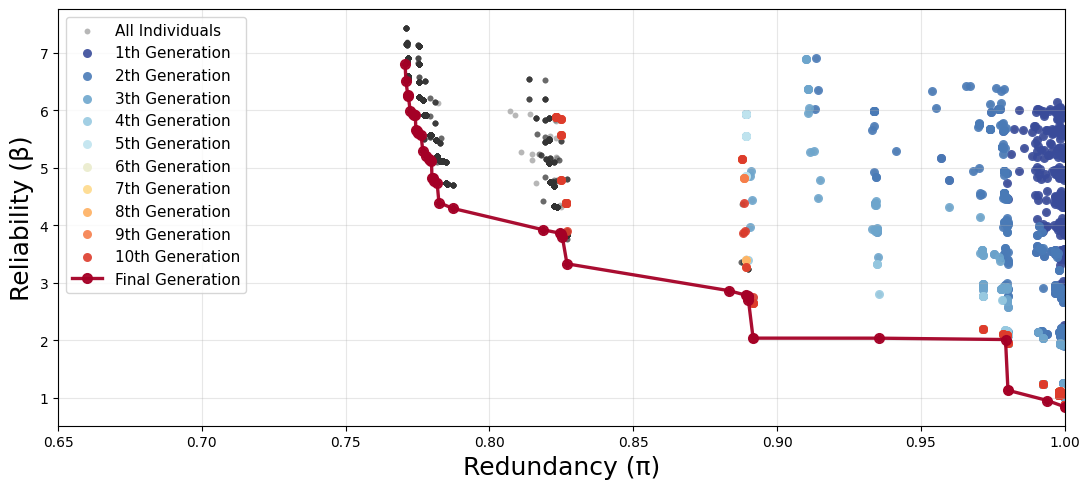

In [14]:
SYS_NAME = "mcnf"      # or "shortest"
DELAY    = 120         # only for mcnf

PROJECT_ROOT = Path.cwd().resolve()
GA_DIR = PROJECT_ROOT
RESULTS_ROOT = GA_DIR / "outputs"
RESULTS_DIR = RESULTS_ROOT / REGION / "Genetic_Algorithm"

if SYS_NAME == "mcnf":
    path = RESULTS_DIR / f"GA_delay{DELAY}_mcnf.json"
elif SYS_NAME == "shortest":
    path = RESULTS_DIR / "GA_shortest.json"
else:
    raise ValueError(f"Unknown SYS_NAME: {SYS_NAME}")

print("Loading:", path)

# Load
data = json.loads(path.read_text(encoding="utf-8"))
gens = data["generations"]

# Prepare
pop_per_gen = [
    [(float(ind["pi"]), float(ind["beta"])) for ind in g["population"]]
    for g in gens
]
pareto_per_gen = [
    [(float(p["pi"]), float(p["beta"])) for p in g.get("pareto", [])] or None
    for g in gens
]

colors = ["#394B9A","#4A7BB7","#6EA6CD","#98CAE1",
          "#C0E4EF","#EAECCC","#FEDA8B","#FEB061",
          "#F67E4B","#DD3C2C"]

# Plot
plt.figure(figsize=(11, 5))

all_pts = [pt for gen_pts in pop_per_gen for pt in gen_pts]
if all_pts:
    plt.scatter(
        [p for p, _ in all_pts],
        [b for _, b in all_pts],
        s=18,
        alpha=0.35,
        color="#333333",
        linewidths=0,
        label="All Individuals"
    )

G = min(10, len(pop_per_gen))
for gi in range(G):
    pts = pop_per_gen[gi]
    if pts:
        plt.scatter(
            [p for p, _ in pts],
            [b for _, b in pts],
            s=42,
            alpha=0.9,
            color=colors[gi],
            linewidths=0,
            label=f"{gi+1}th Generation"
        )

final_idx = len(pop_per_gen) - 1
final_pts = pop_per_gen[final_idx]
final_pareto = pareto_per_gen[final_idx]

if final_pareto and len(final_pareto) >= 2:
    xs = [p for p, _ in final_pareto]
    ys = [b for _, b in final_pareto]
else:
    final_sorted = sorted(final_pts, key=lambda x: x[1])
    xs = [p for p, _ in final_sorted]
    ys = [b for _, b in final_sorted]

if xs and ys:
    plt.plot(
        xs, ys,
        "-o",
        color="#A50026",
        markersize=7,
        linewidth=2.4,
        alpha=0.95,
        label="Final Generation"
    )

plt.xlabel("Redundancy (π)", fontsize=18)
plt.ylabel("Reliability (β)", fontsize=18)
plt.xlim(0.65, 1.0)

if all_pts:
    b_min = min(b for _, b in all_pts)
    b_max = max(b for _, b in all_pts)
    if b_max > b_min:
        pad = 0.05 * (b_max - b_min)
        plt.ylim(b_min - pad, b_max + pad)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc="best")
plt.tight_layout()
plt.show()


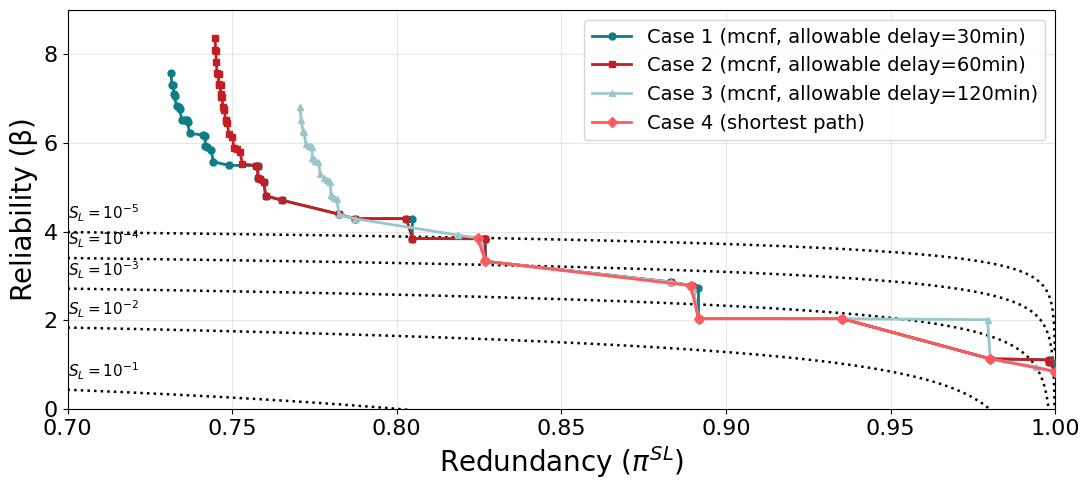

In [15]:
PROJECT_ROOT = Path.cwd().resolve()
base_dir = PROJECT_ROOT / "outputs" / REGION / "Genetic_Algorithm"  

files = [
    ("Case 1 (mcnf, allowable delay=30min)",  base_dir / "GA_delay30_mcnf.json"),
    ("Case 2 (mcnf, allowable delay=60min)",  base_dir / "GA_delay60_mcnf.json"),
    ("Case 3 (mcnf, allowable delay=120min)", base_dir / "GA_delay120_mcnf.json"),
    ("Case 4 (shortest path)",               base_dir / "GA_shortest.json"),
]

styles = [
    dict(color="#0d7d87", marker="o", linestyle="-", linewidth=2.0, markersize=5, zorder=3),
    dict(color="#c31e23", marker="s", linestyle="-", linewidth=2.0, markersize=5, zorder=3),
    dict(color="#99c6cc", marker="^", linestyle="-", linewidth=2.0, markersize=5, zorder=3),
    dict(color="#ff5a5e", marker="D", linestyle="-", linewidth=2.0, markersize=5, zorder=3),
]

# Resilience threshold
DRAW_ISORISK = True
LAMBDA = 1.0
PDM_LIST = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
C_MODE = "one_minus_pi"
LABEL_X_RANGE = (0.00500, 0.0250)

def c_of_pi(pi_arr: np.ndarray, mode: str = "one_minus_pi") -> np.ndarray:
    return 1.0 - pi_arr if mode == "one_minus_pi" else 1.0 - pi_arr

def get_final_points(path: Path):
    data = json.loads(path.read_text(encoding="utf-8"))
    final = data["generations"][-1]
    pts = [(float(p["pi"]), float(p["beta"])) for p in final.get("pareto", [])]
    if not pts:
        pts = [(float(ind["pi"]), float(ind["beta"])) for ind in final["population"]]
    pts.sort(key=lambda x: x[1])
    return pts

def fmt_pdm_label(pdm: float) -> str:
    k = int(np.floor(np.log10(pdm) + 1e-12))
    return rf"$S_{{L}}=10^{{{k}}}$"

def plot_resilience_threshold(ax, pdm, lambda_, c_mode,
                              pi_lo=0.0, pi_hi=0.9999,
                              label_x_range=(0.80, 0.825)):
    pi = np.linspace(pi_lo, pi_hi, 4000)
    c = c_of_pi(pi, mode=c_mode)
    x = np.divide(pdm, lambda_ * c, out=np.full_like(pi, np.nan), where=(c > 0))
    mask = (x > 0.0) & (x < 1.0)
    if not np.any(mask):
        return
    pi_m = pi[mask]
    beta = -norm.ppf(x[mask])
    ax.plot(pi_m, beta, linestyle="dotted", color="k", linewidth=1.8, zorder=2)

    x_lo, x_hi = label_x_range
    sel = (pi_m >= x_lo) & (pi_m <= x_hi)
    idx = np.where(sel)[0][0] if np.any(sel) else min(np.searchsorted(pi_m, x_lo), len(pi_m) - 1)
    xi, yi = pi_m[idx], beta[idx]
    ymin, ymax = ax.get_ylim()
    y_offset = 0.02 * (ymax - ymin)
    ax.text(
        xi, yi + y_offset,
        fmt_pdm_label(pdm),
        color="k", fontsize=11,
        ha="left", va="bottom",
        zorder=3, clip_on=True
    )

# Plot
plt.figure(figsize=(11, 5))
ax = plt.gca()

any_points = False
for (label, path), st in zip(files, styles):
    if not path.exists():
        print(f"[WARN] missing: {path}")
        continue
    pts = get_final_points(path)
    if not pts:
        print(f"[WARN] no points: {path}")
        continue
    xs = [p for p, _ in pts]
    ys = [b for _, b in pts]
    ax.plot(xs, ys, label=label, **st)
    any_points = True

if not any_points:
    raise RuntimeError("No data to plot. Check file paths.")

ax.set_xlabel(r"Redundancy ($\pi^{SL}$)", fontsize=20)
ax.set_ylabel("Reliability (β)", fontsize=20)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.set_xlim(0.7, 1.0)
ax.set_ylim(0.0, 9)
ax.grid(True, alpha=0.3)

if DRAW_ISORISK:
    for pdm in sorted(PDM_LIST, reverse=True):
        plot_resilience_threshold(
            ax, pdm=pdm, lambda_=LAMBDA, c_mode=C_MODE,
            pi_lo=ax.get_xlim()[0],
            pi_hi=min(0.9999, ax.get_xlim()[1]),
            label_x_range=LABEL_X_RANGE,
        )

ax.legend(fontsize=14, loc="upper right")
plt.tight_layout()
plt.show()
